# Extract Environmental Variable from GEE

## Import modules

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

import pandas as pd
import ee
from src.auth import AuthenticationService
from src.variables.ndvi import extract_ndvi
from src.variables.canopy_height import extract_canopy_height
from src.variables.elevation import extract_elevation
from src.variables.landcover import extract_landcover
from src.variables.worldclim import extract_worldclim
from src.variables.biomass import extract_biomass
from src.variables.waterdist import extract_distance_to_water
from src.variables.nighttime_lights import extract_nighttime_lights
from src.variables.bii import extract_bii
from src.variables.satellite_embedding import extract_satellite_embedding
from src.aoi import create_aoi_from_coordinates
from src.utils import plot_map, plot_images
from src.sampling import clean_coordinates_dataframe, convert_points_to_buffered_features
from src.export import export_rasters_to_gdrive, export_csv

from src.hex_grid import generate_h3_hexagons, extract_h3_values

## Setup

In [3]:
GEE_PROJECT_ID = "wide-office-411000"
LOCATIONS_CSV_PATH = "./input/configuration.csv"
OUTPUT_CSV_PATH = "output/env_vars.csv"
OUTPUT_H3_CSV_PATH = "output/hexagons_with_data.csv"
OUTPUT_H3_GPKG_PATH = "output/hexagons_with_data.gpkg"
OUTPUT_H3_SHP_PATH = "output/hexagons.shp"
LAT_COLUMN_NAME = "latitude"
LON_COLUMN_NAME = "longitude"
HEX_RES = 8
SAMPLING_POINT_BUFFER_METERS = 200
AOI_BUFFER_KM = 30
# SERVICE_ACCOUNT = "service-account@google-cloud-project.iam.gserviceaccount.com"
# SERVICE_ACCOUNT_KEY_FILE = "/abs/path/to/service-account-key.json"

In [4]:
ok = AuthenticationService.authenticate(project_id=GEE_PROJECT_ID)
if not ok:
    raise SystemExit("Could not initialize EE")

✅ Google Earth Engine initialized


## Read Coordinates and define points and AOI

In [5]:
df = pd.read_csv(LOCATIONS_CSV_PATH)

df = clean_coordinates_dataframe(df,
                                 lat_col=LAT_COLUMN_NAME,
                                 lon_col=LON_COLUMN_NAME)

points_fc = convert_points_to_buffered_features(df,
                                                lat_col=LAT_COLUMN_NAME,
                                                lon_col=LON_COLUMN_NAME,
                                                buffer_meters=SAMPLING_POINT_BUFFER_METERS)

2025-12-09 09:13:41,092 - INFO - Successfully validated and cleaned 40 points.
2025-12-09 09:13:41,093 - INFO - Preparing sampling units for batch processing...


2025-12-09 09:13:41,106 - INFO - Creating map plot for 40 features...
2025-12-09 09:13:43,338 - INFO - Added basemap: satellite
2025-12-09 09:13:43,353 - INFO - Map plot created successfully


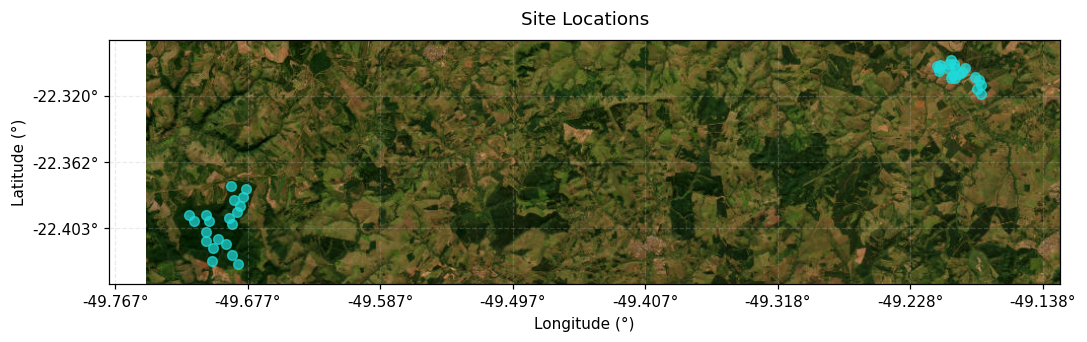

In [6]:
fig, ax = plot_map(df, 
                   basemap='satellite', 
                   alpha=0.7, 
                   color="#1FDBDB", 
                   buffer_pct=0.1,
                   title="Site Locations")  

In [7]:
aoi = create_aoi_from_coordinates(df,
                                  buffer_km=AOI_BUFFER_KM)

📍 AOI Bounds: Lat[-22.6956, -22.0278], Lon[-50.0092, -48.8880]
📊 Defined study area for 40 points with 30km margin.


## Extract variables for each site

In [8]:
# Process NDVI
df, image_ndvi = extract_ndvi(
    df=df,
    aoi=aoi,
    points_feature_collection=points_fc,
    start_date="2025-01-01",
    end_date="2025-12-31",
    scale=30,
    mask_water=True,
    cloud_cover_threshold=50
)
df

2025-12-09 09:13:43,679 - INFO - -----------------------------------------------
2025-12-09 09:13:43,679 - INFO - Starting --NDVI-- extraction...
2025-12-09 09:13:43,680 - INFO - Processing 40 points...
2025-12-09 09:13:43,680 - INFO - Date range: 2025-01-01 to 2025-12-31
2025-12-09 09:13:43,680 - INFO - Scale: 30m
2025-12-09 09:13:43,680 - INFO - Water masking: True
2025-12-09 09:13:43,681 - INFO - Creating Landsat composite for study area...
2025-12-09 09:13:43,955 - INFO - Found 57 Landsat-9 images for study area
2025-12-09 09:13:43,955 - INFO - Loading GLCF water mask...
2025-12-09 09:13:43,957 - INFO - Extracting NDVI statistics for each sampling unit...
2025-12-09 09:13:43,959 - INFO - Fetching results from Earth Engine...
2025-12-09 09:13:44,548 - INFO - Parsing results...
2025-12-09 09:13:44,551 - INFO - Successfully processed 40/40 points
2025-12-09 09:13:44,551 - INFO - NDVI range: 0.423 to 0.882
2025-12-09 09:13:44,552 - INFO - NDVI mean: 0.828 ± 0.101


,site_name,latitude,longitude,filename_offset_hours,folders,tags,NDVI_mean,NDVI_std
0,Caetetus-P01,-22.394977,-49.717152,0,Sao-Paulo/Caetetus-P01,NaN,0.873,0.008
1,Caetetus-P02,-22.398559,-49.713233,0,Sao-Paulo/Caetetus-P02,NaN,0.873,0.007
2,Caetetus-P03,-22.394884,-49.705497,0,Sao-Paulo/Caetetus-P03,NaN,0.873,0.005
3,Caetetus-P04,-22.405722,-49.705396,0,Sao-Paulo/Caetetus-P04,NaN,0.879,0.007
4,Caetetus-P05,-22.411141,-49.705346,0,Sao-Paulo/Caetetus-P05,NaN,0.874,0.009
5,Caetetus-P06,-22.398481,-49.703521,0,Sao-Paulo/Caetetus-P06,NaN,0.878,0.004
6,Caetetus-P07,-22.415340,-49.700660,0,Sao-Paulo/Caetetus-P07,NaN,0.882,0.006
7,Caetetus-P08,-22.423755,-49.701343,0,Sao-Paulo/Caetetus-P08,NaN,0.855,0.012
8,Caetetus-P09,-22.396565,-49.689940,0,Sao-Paulo/Caetetus-P09,NaN,0.875,0.006
9,Caetetus-P10,-22.400162,-49.687963,0,Sao-Paulo/Caetetus-P10,NaN,0.875,0.006


In [9]:
df, image_canopy_height = extract_canopy_height(df,
                                                aoi=aoi,
                                                points_feature_collection=points_fc,
                                                scale=10)
df

2025-12-09 09:13:44,589 - INFO - -----------------------------------------------
2025-12-09 09:13:44,589 - INFO - Starting --Canopy Height-- extraction...
2025-12-09 09:13:44,590 - INFO - Scale: 10m
2025-12-09 09:13:44,590 - INFO - Loading ETH Global Canopy Height dataset...
2025-12-09 09:13:44,590 - INFO - Extracting canopy height statistics...
2025-12-09 09:13:44,592 - INFO - Fetching results from Earth Engine...
2025-12-09 09:13:45,057 - INFO - Merging canopy height values into dataframe...
2025-12-09 09:13:45,058 - INFO - Successfully processed 40/40 points with canopy data
2025-12-09 09:13:45,059 - INFO - Canopy height mean: 20.92 ± 2.58 m (range 11.17-25.28 m)


,site_name,latitude,longitude,filename_offset_hours,folders,tags,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std
0,Caetetus-P01,-22.394977,-49.717152,0,Sao-Paulo/Caetetus-P01,NaN,0.873,0.008,24.002,1.977
1,Caetetus-P02,-22.398559,-49.713233,0,Sao-Paulo/Caetetus-P02,NaN,0.873,0.007,24.315,1.498
2,Caetetus-P03,-22.394884,-49.705497,0,Sao-Paulo/Caetetus-P03,NaN,0.873,0.005,20.190,1.085
3,Caetetus-P04,-22.405722,-49.705396,0,Sao-Paulo/Caetetus-P04,NaN,0.879,0.007,24.765,1.223
4,Caetetus-P05,-22.411141,-49.705346,0,Sao-Paulo/Caetetus-P05,NaN,0.874,0.009,25.284,1.156
5,Caetetus-P06,-22.398481,-49.703521,0,Sao-Paulo/Caetetus-P06,NaN,0.878,0.004,20.721,1.171
6,Caetetus-P07,-22.415340,-49.700660,0,Sao-Paulo/Caetetus-P07,NaN,0.882,0.006,23.404,1.572
7,Caetetus-P08,-22.423755,-49.701343,0,Sao-Paulo/Caetetus-P08,NaN,0.855,0.012,21.327,1.419
8,Caetetus-P09,-22.396565,-49.689940,0,Sao-Paulo/Caetetus-P09,NaN,0.875,0.006,20.186,0.812
9,Caetetus-P10,-22.400162,-49.687963,0,Sao-Paulo/Caetetus-P10,NaN,0.875,0.006,20.219,0.753


In [10]:
df, image_biomass = extract_biomass(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=100,
    year=2022
)
df

2025-12-09 09:13:45,078 - INFO - -----------------------------------------------
2025-12-09 09:13:45,078 - INFO - Starting --Biomass (AGB)-- extraction...
2025-12-09 09:13:45,079 - INFO - Requested year: 2022
2025-12-09 09:13:45,079 - INFO - Scale: 100m
2025-12-09 09:13:45,079 - INFO - Loading ESA CCI AGB image...
2025-12-09 09:13:45,363 - INFO - Extracting biomass statistics...
2025-12-09 09:13:45,364 - INFO - Fetching biomass results from Earth Engine...
2025-12-09 09:13:45,729 - INFO - Merging biomass results into dataframe...
2025-12-09 09:13:45,730 - INFO - Successfully processed 40/40 points with biomass data
2025-12-09 09:13:45,731 - INFO - Biomass mean: 144.63 ± 36.18 t/ha (range 33.51-193.90 t/ha)


,site_name,latitude,longitude,filename_offset_hours,folders,tags,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std,biomass_mean,biomass_std
0,Caetetus-P01,-22.394977,-49.717152,0,Sao-Paulo/Caetetus-P01,NaN,0.873,0.008,24.002,1.977,176.549,22.353
1,Caetetus-P02,-22.398559,-49.713233,0,Sao-Paulo/Caetetus-P02,NaN,0.873,0.007,24.315,1.498,151.292,24.238
2,Caetetus-P03,-22.394884,-49.705497,0,Sao-Paulo/Caetetus-P03,NaN,0.873,0.005,20.190,1.085,152.601,17.887
3,Caetetus-P04,-22.405722,-49.705396,0,Sao-Paulo/Caetetus-P04,NaN,0.879,0.007,24.765,1.223,165.584,15.179
4,Caetetus-P05,-22.411141,-49.705346,0,Sao-Paulo/Caetetus-P05,NaN,0.874,0.009,25.284,1.156,145.717,11.956
5,Caetetus-P06,-22.398481,-49.703521,0,Sao-Paulo/Caetetus-P06,NaN,0.878,0.004,20.721,1.171,147.657,15.327
6,Caetetus-P07,-22.415340,-49.700660,0,Sao-Paulo/Caetetus-P07,NaN,0.882,0.006,23.404,1.572,136.281,17.950
7,Caetetus-P08,-22.423755,-49.701343,0,Sao-Paulo/Caetetus-P08,NaN,0.855,0.012,21.327,1.419,162.832,35.499
8,Caetetus-P09,-22.396565,-49.689940,0,Sao-Paulo/Caetetus-P09,NaN,0.875,0.006,20.186,0.812,136.563,26.625
9,Caetetus-P10,-22.400162,-49.687963,0,Sao-Paulo/Caetetus-P10,NaN,0.875,0.006,20.219,0.753,140.581,25.874


In [11]:
df, image_landcover = extract_landcover(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=10
)
df

2025-12-09 09:13:45,757 - INFO - -----------------------------------------------
2025-12-09 09:13:45,757 - INFO - Starting --ESA WorldCover-- extraction...
2025-12-09 09:13:45,757 - INFO - Date range: 2021
2025-12-09 09:13:45,757 - INFO - Scale: 10m
2025-12-09 09:13:45,757 - INFO - Loading ESA WorldCover composite for study area...
2025-12-09 09:13:45,758 - INFO - Extracting dominant landcover and class proportions...
2025-12-09 09:13:45,762 - INFO - Fetching landcover statistics from Earth Engine...
2025-12-09 09:13:46,234 - INFO - Merging landcover results into dataframe...
2025-12-09 09:13:46,238 - INFO - Successfully processed 40/40 points with landcover data
2025-12-09 09:13:46,239 - INFO - Dominant landcover distribution:
2025-12-09 09:13:46,239 - INFO -   Tree_cover: 40 points (100.0%)


,site_name,latitude,longitude,filename_offset_hours,folders,tags,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std,...,landcover_prop_Grassland,landcover_prop_Cropland,landcover_prop_Built_up,landcover_prop_Bare_sparse_vegetation,landcover_prop_Snow_and_ice,landcover_prop_Permanent_water_bodies,landcover_prop_Herbaceous_wetland,landcover_prop_Mangroves,landcover_prop_Moss_and_lichen,landcover_dominant_label
0,Caetetus-P01,-22.394977,-49.717152,0,Sao-Paulo/Caetetus-P01,NaN,0.873,0.008,24.002,1.977,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
1,Caetetus-P02,-22.398559,-49.713233,0,Sao-Paulo/Caetetus-P02,NaN,0.873,0.007,24.315,1.498,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
2,Caetetus-P03,-22.394884,-49.705497,0,Sao-Paulo/Caetetus-P03,NaN,0.873,0.005,20.190,1.085,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
3,Caetetus-P04,-22.405722,-49.705396,0,Sao-Paulo/Caetetus-P04,NaN,0.879,0.007,24.765,1.223,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
4,Caetetus-P05,-22.411141,-49.705346,0,Sao-Paulo/Caetetus-P05,NaN,0.874,0.009,25.284,1.156,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
5,Caetetus-P06,-22.398481,-49.703521,0,Sao-Paulo/Caetetus-P06,NaN,0.878,0.004,20.721,1.171,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
6,Caetetus-P07,-22.415340,-49.700660,0,Sao-Paulo/Caetetus-P07,NaN,0.882,0.006,23.404,1.572,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
7,Caetetus-P08,-22.423755,-49.701343,0,Sao-Paulo/Caetetus-P08,NaN,0.855,0.012,21.327,1.419,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
8,Caetetus-P09,-22.396565,-49.689940,0,Sao-Paulo/Caetetus-P09,NaN,0.875,0.006,20.186,0.812,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
9,Caetetus-P10,-22.400162,-49.687963,0,Sao-Paulo/Caetetus-P10,NaN,0.875,0.006,20.219,0.753,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover


In [12]:
df, image_elevation = extract_elevation(df=df,
                                        aoi=aoi,
                                        points_feature_collection=points_fc,
                                        scale=30)
df

2025-12-09 09:13:46,274 - INFO - -----------------------------------------------
2025-12-09 09:13:46,274 - INFO - Starting --Elevation & Slope-- extraction...
2025-12-09 09:13:46,274 - INFO - Scale: 30m
2025-12-09 09:13:46,274 - INFO - Loading SRTM elevation dataset...
2025-12-09 09:13:46,275 - INFO - Extracting elevation and slope statistics...
2025-12-09 09:13:46,277 - INFO - Fetching results from Earth Engine...
2025-12-09 09:13:46,696 - INFO - Merging elevation and slope values into dataframe...
2025-12-09 09:13:46,698 - INFO - Successfully processed 40/40 points with elevation data
2025-12-09 09:13:46,698 - INFO - Successfully processed 40/40 points with slope data
2025-12-09 09:13:46,699 - INFO - Elevation mean: 561.38 ± 62.01 m (range 485.55-672.30 m)
2025-12-09 09:13:46,701 - INFO - Slope mean: 11.79 ± 4.57 deg (range 3.60-25.99 deg)


,site_name,latitude,longitude,filename_offset_hours,folders,tags,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std,...,landcover_prop_Snow_and_ice,landcover_prop_Permanent_water_bodies,landcover_prop_Herbaceous_wetland,landcover_prop_Mangroves,landcover_prop_Moss_and_lichen,landcover_dominant_label,elevation_mean,elevation_std,slope_percent_mean,slope_percent_std
0,Caetetus-P01,-22.394977,-49.717152,0,Sao-Paulo/Caetetus-P01,NaN,0.873,0.008,24.002,1.977,...,0.0,0.0,0.0,0.0,0.0,Tree_cover,571.352,19.339,25.994,10.013
1,Caetetus-P02,-22.398559,-49.713233,0,Sao-Paulo/Caetetus-P02,NaN,0.873,0.007,24.315,1.498,...,0.0,0.0,0.0,0.0,0.0,Tree_cover,566.977,22.403,21.501,8.994
2,Caetetus-P03,-22.394884,-49.705497,0,Sao-Paulo/Caetetus-P03,NaN,0.873,0.005,20.190,1.085,...,0.0,0.0,0.0,0.0,0.0,Tree_cover,656.217,1.834,3.598,1.845
3,Caetetus-P04,-22.405722,-49.705396,0,Sao-Paulo/Caetetus-P04,NaN,0.879,0.007,24.765,1.223,...,0.0,0.0,0.0,0.0,0.0,Tree_cover,579.841,9.098,13.382,4.830
4,Caetetus-P05,-22.411141,-49.705346,0,Sao-Paulo/Caetetus-P05,NaN,0.874,0.009,25.284,1.156,...,0.0,0.0,0.0,0.0,0.0,Tree_cover,557.609,11.522,12.467,5.742
5,Caetetus-P06,-22.398481,-49.703521,0,Sao-Paulo/Caetetus-P06,NaN,0.878,0.004,20.721,1.171,...,0.0,0.0,0.0,0.0,0.0,Tree_cover,647.167,6.935,8.018,4.221
6,Caetetus-P07,-22.415340,-49.700660,0,Sao-Paulo/Caetetus-P07,NaN,0.882,0.006,23.404,1.572,...,0.0,0.0,0.0,0.0,0.0,Tree_cover,569.591,6.599,8.696,4.167
7,Caetetus-P08,-22.423755,-49.701343,0,Sao-Paulo/Caetetus-P08,NaN,0.855,0.012,21.327,1.419,...,0.0,0.0,0.0,0.0,0.0,Tree_cover,519.375,10.707,14.335,7.161
8,Caetetus-P09,-22.396565,-49.689940,0,Sao-Paulo/Caetetus-P09,NaN,0.875,0.006,20.186,0.812,...,0.0,0.0,0.0,0.0,0.0,Tree_cover,651.672,5.059,6.151,4.220
9,Caetetus-P10,-22.400162,-49.687963,0,Sao-Paulo/Caetetus-P10,NaN,0.875,0.006,20.219,0.753,...,0.0,0.0,0.0,0.0,0.0,Tree_cover,653.477,7.505,8.404,4.626


In [13]:
df, image_waterdist = extract_distance_to_water(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=30,
    max_search_distance=20_000,
)
df

2025-12-09 09:13:46,736 - INFO - -----------------------------------------------
2025-12-09 09:13:46,737 - INFO - Starting --Distance to Water-- extraction...
2025-12-09 09:13:46,737 - INFO - Sampling scale: 30m
2025-12-09 09:13:46,737 - INFO - Max search distance: 20000m, pixels beyond this will be set to 20001m
2025-12-09 09:13:46,737 - INFO - Loading water datasets at native resolution...
2025-12-09 09:13:46,738 - INFO - Combining water layers...
2025-12-09 09:13:46,739 - INFO - Building distance surface using FDT...
2025-12-09 09:13:46,740 - INFO - Sampling distance values at sampling point centroids...
2025-12-09 09:13:46,743 - INFO - Fetching distance results...
2025-12-09 09:13:47,188 - INFO - Merging distances into dataframe...
2025-12-09 09:13:47,189 - INFO - Successfully processed 40/40 points with distance-to-water data
2025-12-09 09:13:47,190 - INFO - Distance to water: median 5066.8 m (min 900.0 m, max 10536.5 m)


,site_name,latitude,longitude,filename_offset_hours,folders,tags,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std,...,landcover_prop_Permanent_water_bodies,landcover_prop_Herbaceous_wetland,landcover_prop_Mangroves,landcover_prop_Moss_and_lichen,landcover_dominant_label,elevation_mean,elevation_std,slope_percent_mean,slope_percent_std,distance_to_water_m
0,Caetetus-P01,-22.394977,-49.717152,0,Sao-Paulo/Caetetus-P01,NaN,0.873,0.008,24.002,1.977,...,0.0,0.0,0.0,0.0,Tree_cover,571.352,19.339,25.994,10.013,6091.182
1,Caetetus-P02,-22.398559,-49.713233,0,Sao-Paulo/Caetetus-P02,NaN,0.873,0.007,24.315,1.498,...,0.0,0.0,0.0,0.0,Tree_cover,566.977,22.403,21.501,8.994,6047.586
2,Caetetus-P03,-22.394884,-49.705497,0,Sao-Paulo/Caetetus-P03,NaN,0.873,0.005,20.190,1.085,...,0.0,0.0,0.0,0.0,Tree_cover,656.217,1.834,3.598,1.845,6960.000
3,Caetetus-P04,-22.405722,-49.705396,0,Sao-Paulo/Caetetus-P04,NaN,0.879,0.007,24.765,1.223,...,0.0,0.0,0.0,0.0,Tree_cover,579.841,9.098,13.382,4.830,6141.799
4,Caetetus-P05,-22.411141,-49.705346,0,Sao-Paulo/Caetetus-P05,NaN,0.874,0.009,25.284,1.156,...,0.0,0.0,0.0,0.0,Tree_cover,557.609,11.522,12.467,5.742,5790.000
5,Caetetus-P06,-22.398481,-49.703521,0,Sao-Paulo/Caetetus-P06,NaN,0.878,0.004,20.721,1.171,...,0.0,0.0,0.0,0.0,Tree_cover,647.167,6.935,8.018,4.221,6837.170
6,Caetetus-P07,-22.415340,-49.700660,0,Sao-Paulo/Caetetus-P07,NaN,0.882,0.006,23.404,1.572,...,0.0,0.0,0.0,0.0,Tree_cover,569.591,6.599,8.696,4.167,6050.785
7,Caetetus-P08,-22.423755,-49.701343,0,Sao-Paulo/Caetetus-P08,NaN,0.855,0.012,21.327,1.419,...,0.0,0.0,0.0,0.0,Tree_cover,519.375,10.707,14.335,7.161,5653.548
8,Caetetus-P09,-22.396565,-49.689940,0,Sao-Paulo/Caetetus-P09,NaN,0.875,0.006,20.186,0.812,...,0.0,0.0,0.0,0.0,Tree_cover,651.672,5.059,6.151,4.220,8204.438
9,Caetetus-P10,-22.400162,-49.687963,0,Sao-Paulo/Caetetus-P10,NaN,0.875,0.006,20.219,0.753,...,0.0,0.0,0.0,0.0,Tree_cover,653.477,7.505,8.404,4.626,8139.349


In [14]:
df, image_bii = extract_bii(
    df=df,
    aoi=aoi,
    points_feature_collection=points_fc,
    year=2020,
    scale=100
)

2025-12-09 09:13:47,220 - INFO - -----------------------------------------------
2025-12-09 09:13:47,221 - INFO - Starting --Biodiversity Intactness Index-- extraction...
2025-12-09 09:13:47,221 - INFO - Requested year: 2020
2025-12-09 09:13:47,221 - INFO - Scale: 100m
2025-12-09 09:13:47,221 - INFO - Loading BII image...
2025-12-09 09:13:47,542 - INFO - Extracting BII statistics...
2025-12-09 09:13:47,544 - INFO - Fetching BII results from Earth Engine...
2025-12-09 09:13:47,921 - INFO - Merging BII results into dataframe...
2025-12-09 09:13:47,922 - INFO - Successfully processed 40/40 points with BII data
2025-12-09 09:13:47,923 - INFO - BII mean: 0.73 ± 0.17 (range 0.34-0.92)


In [15]:
df, image_nightlights = extract_nighttime_lights(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=464,
    year=2022
)
df

2025-12-09 09:13:47,929 - INFO - -----------------------------------------------
2025-12-09 09:13:47,929 - INFO - Starting --Nighttime Lights-- extraction...
2025-12-09 09:13:47,929 - INFO - Requested year: 2022
2025-12-09 09:13:47,929 - INFO - Scale: 464m
2025-12-09 09:13:47,930 - INFO - Loading VIIRS annual nighttime lights image...
2025-12-09 09:13:48,212 - INFO - Extracting nighttime lights statistics...
2025-12-09 09:13:48,214 - INFO - Fetching nighttime lights results from Earth Engine...
2025-12-09 09:13:48,562 - INFO - Merging nighttime lights results into dataframe...
2025-12-09 09:13:48,564 - INFO - Successfully processed 40/40 points with nighttime lights data
2025-12-09 09:13:48,564 - INFO - Nighttime lights mean: 0.49 ± 0.14 (range 0.32-0.71)


,site_name,latitude,longitude,filename_offset_hours,folders,tags,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std,...,landcover_dominant_label,elevation_mean,elevation_std,slope_percent_mean,slope_percent_std,distance_to_water_m,biointactness_mean,biointactness_std,nightlights_mean,nightlights_std
0,Caetetus-P01,-22.394977,-49.717152,0,Sao-Paulo/Caetetus-P01,NaN,0.873,0.008,24.002,1.977,...,Tree_cover,571.352,19.339,25.994,10.013,6091.182,0.868,0.010,0.402,0.031
1,Caetetus-P02,-22.398559,-49.713233,0,Sao-Paulo/Caetetus-P02,NaN,0.873,0.007,24.315,1.498,...,Tree_cover,566.977,22.403,21.501,8.994,6047.586,0.892,0.003,0.377,0.012
2,Caetetus-P03,-22.394884,-49.705497,0,Sao-Paulo/Caetetus-P03,NaN,0.873,0.005,20.190,1.085,...,Tree_cover,656.217,1.834,3.598,1.845,6960.000,0.868,0.010,0.386,0.015
3,Caetetus-P04,-22.405722,-49.705396,0,Sao-Paulo/Caetetus-P04,NaN,0.879,0.007,24.765,1.223,...,Tree_cover,579.841,9.098,13.382,4.830,6141.799,0.912,0.000,0.350,0.002
4,Caetetus-P05,-22.411141,-49.705346,0,Sao-Paulo/Caetetus-P05,NaN,0.874,0.009,25.284,1.156,...,Tree_cover,557.609,11.522,12.467,5.742,5790.000,0.916,0.000,0.341,0.005
5,Caetetus-P06,-22.398481,-49.703521,0,Sao-Paulo/Caetetus-P06,NaN,0.878,0.004,20.721,1.171,...,Tree_cover,647.167,6.935,8.018,4.221,6837.170,0.893,0.009,0.357,0.014
6,Caetetus-P07,-22.415340,-49.700660,0,Sao-Paulo/Caetetus-P07,NaN,0.882,0.006,23.404,1.572,...,Tree_cover,569.591,6.599,8.696,4.167,6050.785,0.911,0.007,0.340,0.006
7,Caetetus-P08,-22.423755,-49.701343,0,Sao-Paulo/Caetetus-P08,NaN,0.855,0.012,21.327,1.419,...,Tree_cover,519.375,10.707,14.335,7.161,5653.548,0.831,0.027,0.337,0.011
8,Caetetus-P09,-22.396565,-49.689940,0,Sao-Paulo/Caetetus-P09,NaN,0.875,0.006,20.186,0.812,...,Tree_cover,651.672,5.059,6.151,4.220,8204.438,0.894,0.002,0.365,0.011
9,Caetetus-P10,-22.400162,-49.687963,0,Sao-Paulo/Caetetus-P10,NaN,0.875,0.006,20.219,0.753,...,Tree_cover,653.477,7.505,8.404,4.626,8139.349,0.885,0.005,0.358,0.008


In [16]:
# Do not save embeddings images for now
df, _ = extract_satellite_embedding(
    df=df,
    aoi=aoi,
    points_feature_collection=points_fc,
    year=2024,
    scale=10
)

2025-12-09 09:13:48,606 - INFO - -----------------------------------------------
2025-12-09 09:13:48,606 - INFO - Starting --Satellite Embedding V1-- extraction...
2025-12-09 09:13:48,607 - INFO - Requested year: 2024
2025-12-09 09:13:48,607 - INFO - Scale: 10m
2025-12-09 09:13:48,607 - INFO - Loading Satellite Embedding image...
2025-12-09 09:13:48,854 - INFO - Extracting embedding vectors...
2025-12-09 09:13:48,857 - INFO - Fetching embedding results from Earth Engine...
2025-12-09 09:13:49,283 - INFO - Merging embeddings into dataframe...
2025-12-09 09:13:49,284 - INFO - Successfully processed 40/40 points with satellite embeddings


In [17]:
df, image_worldclim = extract_worldclim(df,
                                        aoi=aoi,
                                        points_feature_collection=points_fc,
                                        variables=['bio01', 'bio02'], # comment/uncomment to select all/specific variables
                                        )
df

2025-12-09 09:13:49,290 - INFO - -----------------------------------------------
2025-12-09 09:13:49,290 - INFO - Starting --WorldClim-- extraction...
2025-12-09 09:13:49,290 - INFO - Variables: bio01, bio02
2025-12-09 09:13:49,291 - INFO - Scale: 1000m
2025-12-09 09:13:49,291 - INFO - Loading WorldClim image for study area...
2025-12-09 09:13:49,291 - INFO - Extracting bioclimatic statistics...
2025-12-09 09:13:49,293 - INFO - Fetching results from Earth Engine...
2025-12-09 09:13:49,768 - INFO - Merging WorldClim results into dataframe...
2025-12-09 09:13:49,770 - INFO - Successfully processed 40/40 points with WorldClim data
2025-12-09 09:13:49,770 - INFO - Annual Mean Temperature (bio01): 19.9°C to 21.2°C (mean 20.7°C)


,site_name,latitude,longitude,filename_offset_hours,folders,tags,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std,...,distance_to_water_m,biointactness_mean,biointactness_std,nightlights_mean,nightlights_std,satellite_embeddings_v1,bio01_mean,bio01_stdDev,bio02_mean,bio02_stdDev
0,Caetetus-P01,-22.394977,-49.717152,0,Sao-Paulo/Caetetus-P01,NaN,0.873,0.008,24.002,1.977,...,6091.182,0.868,0.010,0.402,0.031,"[0.1003209376225104, 0.039671364736450436, -0....",20.357,0.050,12.757,0.050
1,Caetetus-P02,-22.398559,-49.713233,0,Sao-Paulo/Caetetus-P02,NaN,0.873,0.007,24.315,1.498,...,6047.586,0.892,0.003,0.377,0.012,"[0.1011665849113486, 0.019316691241436156, -0....",20.600,0.000,12.800,0.000
2,Caetetus-P03,-22.394884,-49.705497,0,Sao-Paulo/Caetetus-P03,NaN,0.873,0.005,20.190,1.085,...,6960.000,0.868,0.010,0.386,0.015,"[0.13268899677605495, 0.04686254921414718, -0....",20.100,0.000,12.700,0.000
3,Caetetus-P04,-22.405722,-49.705396,0,Sao-Paulo/Caetetus-P04,NaN,0.879,0.007,24.765,1.223,...,6141.799,0.912,0.000,0.350,0.002,"[0.10833256590063069, 0.009720595601538946, -0...",20.500,0.000,12.800,0.000
4,Caetetus-P05,-22.411141,-49.705346,0,Sao-Paulo/Caetetus-P05,NaN,0.874,0.009,25.284,1.156,...,5790.000,0.916,0.000,0.341,0.005,"[0.10057408487601552, -0.000611199234912137, -...",20.500,0.000,12.800,0.000
5,Caetetus-P06,-22.398481,-49.703521,0,Sao-Paulo/Caetetus-P06,NaN,0.878,0.004,20.721,1.171,...,6837.170,0.893,0.009,0.357,0.014,"[0.1508951648781839, 0.04151456876454716, -0.1...",20.500,0.000,12.800,0.000
6,Caetetus-P07,-22.415340,-49.700660,0,Sao-Paulo/Caetetus-P07,NaN,0.882,0.006,23.404,1.572,...,6050.785,0.911,0.007,0.340,0.006,"[0.12299556932079951, 0.013449921384273918, -0...",20.694,0.122,12.800,0.000
7,Caetetus-P08,-22.423755,-49.701343,0,Sao-Paulo/Caetetus-P08,NaN,0.855,0.012,21.327,1.419,...,5653.548,0.831,0.027,0.337,0.011,"[0.11432365879695247, 0.039389250035737705, -0...",20.832,0.050,12.800,0.000
8,Caetetus-P09,-22.396565,-49.689940,0,Sao-Paulo/Caetetus-P09,NaN,0.875,0.006,20.186,0.812,...,8204.438,0.894,0.002,0.365,0.011,"[0.1477756392580406, 0.04196246828739002, -0.1...",20.345,0.229,12.755,0.043
9,Caetetus-P10,-22.400162,-49.687963,0,Sao-Paulo/Caetetus-P10,NaN,0.875,0.006,20.219,0.753,...,8139.349,0.885,0.005,0.358,0.008,"[0.14733000431691887, 0.03338880289871649, -0....",20.400,0.000,12.800,0.000


## Export results CSV

In [ ]:
export_csv(df, OUTPUT_CSV_PATH)

## Select variables for AOI operations (Raster and HexGrid exports)

In [18]:
# Select variables that you want to include in the image stack for the rasters and hexgrid exports
image_stack = ee.Image.cat([
    image_ndvi,
    image_canopy_height,
    image_biomass,
    image_landcover,
    image_elevation,
    image_waterdist,
    image_bii,
    image_nightlights,
    image_worldclim,
])

Plot any raster before any exporting if you want to double check them

In [19]:
# map = plot_images(image_stack,
#                   aoi=aoi,
#                   zoom=10,
#                   scale=30,
#                   filter_bands=['elevation'],
#                   )
# map

## Export raw rasters

In [20]:
## Uncomment to export raw rasters
# export_rasters_to_gdrive(
#    image=image_stack,
#    region=aoi,
#    file_name_prefix="2025",
#    scale=200,
#    crs="EPSG:3857",
#    file_format="GeoTIFF")

## Creating hexagon and extraction values

In [39]:
hex_gdf = generate_h3_hexagons(aoi=aoi, h3_resolution=7)
hex_gdf

,geometry,h3_id,hexagon_area_km2,hexagon_area_m2
0,"POLYGON ((-49.37041 -22.17794, -49.36301 -22.1...",87a81dcf0ffffff,5.262113,5.262113e+06
1,"POLYGON ((-48.90771 -22.29303, -48.90029 -22.2...",87a81c236ffffff,5.267447,5.267447e+06
2,"POLYGON ((-49.93254 -22.53214, -49.92514 -22.5...",87a8032d2ffffff,5.210975,5.210975e+06
3,"POLYGON ((-49.20481 -22.29681, -49.1974 -22.28...",87a81c369ffffff,5.257325,5.257325e+06
4,"POLYGON ((-49.90814 -22.43637, -49.90074 -22.4...",87a81d908ffffff,5.220319,5.220319e+06
...,...,...,...,...
1629,"POLYGON ((-49.68616 -22.12539, -49.67876 -22.1...",87a81d106ffffff,5.255592,5.255592e+06
1630,"POLYGON ((-49.77276 -22.185, -49.76536 -22.174...",87a81d8d6ffffff,5.247277,5.247277e+06
1631,"POLYGON ((-49.38047 -22.48114, -49.37306 -22.4...",87a81dd30ffffff,5.235090,5.235090e+06
1632,"POLYGON ((-49.82008 -22.33382, -49.81268 -22.3...",87a81d815ffffff,5.232546,5.232546e+06


In [40]:
image_dict_no_categorical = {
    'ndvi': (image_ndvi, 30),
    'canopy_height': (image_canopy_height, 10),
    'biomass': (image_biomass, 100),
    'elevation': (image_elevation.select('elevation'), 30),
    'slope': (image_elevation.select('slope_percent'), 30),
    'water_dist': (image_waterdist, 30),
    'bii': (image_bii, 100),
    'nightlights': (image_nightlights, 464),
    'bio1': (image_worldclim.select('bio01'), 1000),
    'bio12': (image_worldclim.select('bio02'), 1000),
    'landcover': (image_landcover, 10, "mode")
}

In [41]:
hexagons_with_data = extract_h3_values(
    hex_gdf=hex_gdf,
    image_dict=image_dict_no_categorical,
    batch_size=100,
    tileScale=4,
    default_reducer = 'median',
)

2025-12-09 16:09:43,288 - INFO - Created 1,634 records


Converting entire hex grid to Earth Engine only once...
Using custom scales per band...
Validating images...
  ✓ ndvi: 30m, median - band: ndvi
  ✓ canopy_height: 10m, median - band: canopy_height
  ✓ biomass: 100m, median - band: agb
  ✓ elevation: 30m, median - band: elevation
  ✓ slope: 30m, median - band: slope_percent
  ⚠️  'water_dist' has 2 bands: ['water_mask', 'distance_to_water_m']
      Selecting first band: 'water_mask'
  ✓ water_dist: 30m, median - band: water_mask
  ✓ bii: 100m, median - band: biointactness
  ✓ nightlights: 464m, median - band: nighttime_lights
  ✓ bio1: 1000m, median - band: bio01
  ✓ bio12: 1000m, median - band: bio02
  ✓ landcover: 10m, mode - band: land_cover

Total hexagons to process: 1634
Scale-Reducer groups: [((30, 'median'), 4), ((10, 'median'), 1), ((100, 'median'), 2), ((464, 'median'), 1), ((1000, 'median'), 2), ((10, 'mode'), 1)]


ndvi:   0%|          | 0/1634 [00:00<?, ?hex/s]

canopy_height:   0%|          | 0/1634 [00:00<?, ?hex/s]

biomass:   0%|          | 0/1634 [00:00<?, ?hex/s]

...

nightlights:   0%|          | 0/1634 [00:00<?, ?hex/s]

bio1:   0%|          | 0/1634 [00:00<?, ?hex/s]

bio12:   0%|          | 0/1634 [00:00<?, ?hex/s]

landcover:   0%|          | 0/1634 [00:00<?, ?hex/s]


✓ ALL DONE!
  ndvi (median): 1634/1634 non-null values
  canopy_height (median): 1634/1634 non-null values
  biomass (median): 1633/1634 non-null values
  elevation (median): 1634/1634 non-null values
  slope (median): 1634/1634 non-null values
  water_dist (median): 204/1634 non-null values
  bii (median): 1634/1634 non-null values
  nightlights (median): 1634/1634 non-null values
  bio1 (median): 1634/1634 non-null values
  bio12 (median): 1634/1634 non-null values
  landcover (mode): 1634/1634 non-null values


In [31]:
hexagons_with_data

,geometry,h3_id,hexagon_area_km2,hexagon_area_m2,ndvi,canopy_height,biomass,elevation,slope,water_dist,bii,nightlights,bio1,bio12,landcover
0,"POLYGON ((-49.37041 -22.17794, -49.36301 -22.1...",87a81dcf0ffffff,5.262113,5.262113e+06,0.83305,30,22,540.739987,7.619908,None,0.62592,0.355599,20.9,12.7,10.0
1,"POLYGON ((-48.90771 -22.29303, -48.90029 -22.2...",87a81c236ffffff,5.267447,5.267447e+06,0.607465,3,4,541.265324,3.686845,None,0.479507,0.594111,20.9,12.6,40.0
2,"POLYGON ((-49.93254 -22.53214, -49.92514 -22.5...",87a8032d2ffffff,5.210975,5.210975e+06,0.665984,0,14,541.230519,3.563988,None,0.51442,0.308536,20.9,12.7,40
3,"POLYGON ((-49.20481 -22.29681, -49.1974 -22.28...",87a81c369ffffff,5.257325,5.257325e+06,0.816498,13.82381,42.086042,510.755361,8.877679,None,0.572141,0.529525,21,12.8,10.0
4,"POLYGON ((-49.90814 -22.43637, -49.90074 -22.4...",87a81d908ffffff,5.220319,5.220319e+06,0.650467,8.391047,11.0,551.750372,9.132955,1,0.528982,0.448832,20.6,12.7,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1629,"POLYGON ((-49.68616 -22.12539, -49.67876 -22.1...",87a81d106ffffff,5.255592,5.255592e+06,0.810716,32.206929,61,619.534803,7.239628,None,0.598632,0.423503,20.200001,12.7,10
1630,"POLYGON ((-49.77276 -22.185, -49.76536 -22.174...",87a81d8d6ffffff,5.247277,5.247277e+06,0.697381,11.492294,30,498.473878,11.761616,None,0.607261,0.484995,20.799999,12.7,30.0
1631,"POLYGON ((-49.38047 -22.48114, -49.37306 -22.4...",87a81dd30ffffff,5.235090,5.235090e+06,0.566096,0,14.528646,558.771667,6.122476,None,0.485218,0.387798,20.799999,12.8,40.0
1632,"POLYGON ((-49.82008 -22.33382, -49.81268 -22.3...",87a81d815ffffff,5.232546,5.232546e+06,0.685425,8.027299,21,634.571807,12.26156,None,0.52919,0.394023,20.200001,12.7,30.0


<Axes: >

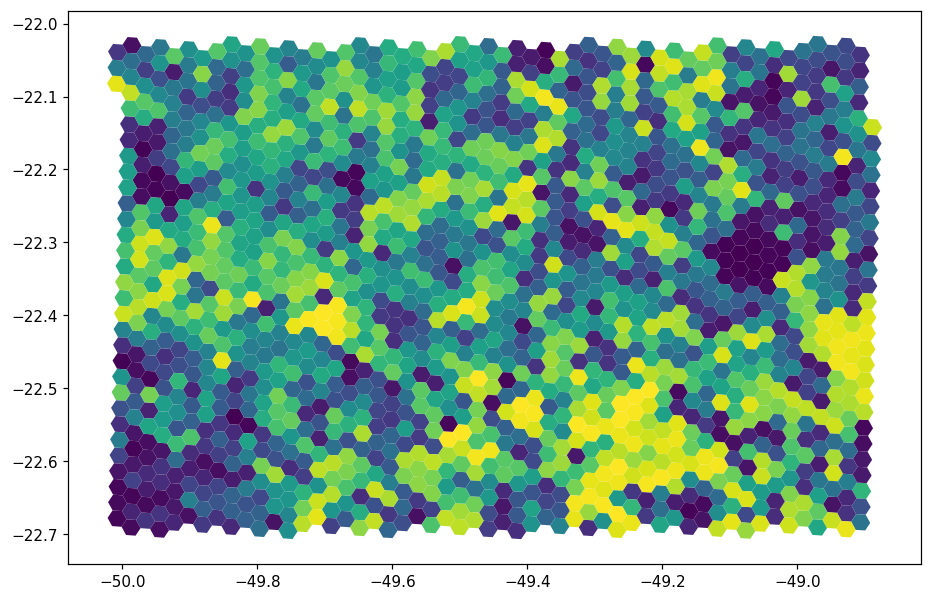

In [32]:
hexagons_with_data.plot(column='ndvi', legend=False, cmap='viridis', figsize=(10, 8))


In [ ]:
hexagons_with_data.to_csv(OUTPUT_H3_CSV_PATH, index=False)
hexagons_with_data.to_file(OUTPUT_H3_GPKG_PATH)
hexagons_with_data.to_file(OUTPUT_H3_SHP_PATH)

___